In [1]:
from mxlmodels import Simulator, get_lazar1997, plot
import matplotlib.pyplot as plt
import numpy as np

# this model needs assimulo for proper integration

## Figure 2

In [2]:
res_fig2 = (
    Simulator(get_lazar1997())
    .simulate_time_course(np.linspace(0, 1, int(1e5)))
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

(-0.01, 1.0)

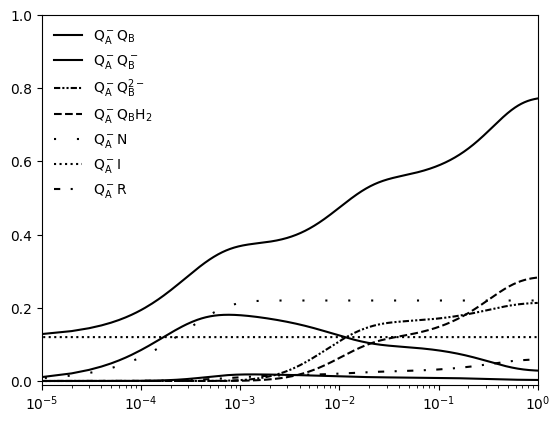

In [3]:

fig, ax = plt.subplots()

to_plot = {
    "F": {},
    "y2": {"label": r"$\mathrm{Q_A^-Q_B}$", "ls": "-"},
    "y4": {"label": r"$\mathrm{Q_A^-Q_B^-}$", "ls": "-"},
    "y6": {"label": r"$\mathrm{Q_A^-Q_B^{2-}}$", "ls": (0, (3, 1, 1, 1, 1, 1))},
    "y8": {"label": r"$\mathrm{Q_A^-Q_BH_2}$", "ls": "--"},
    "y14": {"label": r"$\mathrm{Q_A^-N}$", "ls": (0, (1, 10))},
    "y15": {"label": r"$\mathrm{Q_A^-I}$", "ls": ":"},
    "y12": {"label": r"$\mathrm{Q_A^-R}$", "ls": (0, (3, 5, 1, 5))},
}

for var, dic in to_plot.items():
    ax.plot(res_fig2[var], color="black", **dic)

ax.legend(frameon=False)
ax.set_xscale("log")
ax.set_xlim(1e-5, 1e0)
ax.set_ylim(-0.01, 1)

In [25]:
from mxlpy import Simulator, plot
import matplotlib.pyplot as plt
from mxlpy import scan
import pandas as pd

factors = [0, 0.9, 0.77, 0.5, 1]

res_fig3 = scan.time_course(
    model=get_lazar1997(),
    time_points=np.linspace(0, 1, int(1e5)),
    to_scan=pd.DataFrame({
        "k6": [3500 * (1 - a) for a in factors],
        "k7": [175 * (1 - a) for a in factors],
        "k8": [1750 * (1 - a) for a in factors],
        "k9": [35 * (1 - a) for a in factors],
        "k16": [150 * (1 - a) for a in factors],
        "k17": [100 * (1 - a) for a in factors],
        "k22": [150 * (1 - a) for a in factors],
        "k23": [100 * (1 - a) for a in factors]
    }, index=factors)
)





# res_fig3 = {}
# for a in [0, 0.9, 0.77, 0.5, 1]:
#     res_fig3[a] = (
#         Simulator(
#                 get_lazar1997().update_parameters(
#                     {
#                         "k6": 3500 * (1 - a),
#                         "k7": 175 * (1 - a),
#                         "k8": 1750 * (1 - a),
#                         "k9": 35 * (1 - a),
#                         "k16": 150 * (1 - a),
#                         "k17": 100 * (1 - a),
#                         "k22": 150 * (1 - a),
#                         "k23": 100 * (1 - a),
#                     }
#                 )
#             )
#         .simulate_time_course(np.linspace(0, 1, int(1e5)))
#         .get_result()
#         .unwrap_or_err()
#         .get_combined()
#     )
    


100%|██████████| 5/5 [00:02<00:00,  1.97it/s]


In [40]:
res_fig3.variables.index.get_level_values(0).unique()

Index([0.0, 0.9, 0.77, 0.5, 1.0], dtype='float64', name='n')

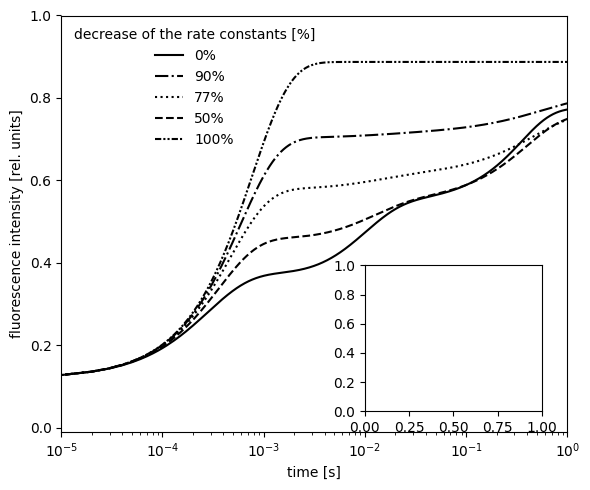

In [ ]:

fig, ax = plt.subplots(figsize=(6, 5))

ls_dict = {
    0: "-",
    0.5: "--",
    0.77: ":",
    0.9: "-.",
    1: (0, (3, 1, 1, 1, 1, 1))
}

for a in factors:
    res = res_fig3.variables.loc[a]
    ax.plot(res["F"], color="black", label=f"{a * 100:.0f}%", linestyle=ls_dict.get(a, "-"))


ax.legend(frameon=False, title="decrease of the rate constants [%]", loc="upper left")
ax.set_xscale("log")
ax.set_xlim(1e-5, 1e0)
ax.set_xlabel("time [s]")
ax.set_ylim(-0.01, 1)
ax.set_ylabel("fluorescence intensity [rel. units]")

ax_inset = ax.inset_axes([0.6, 0.05, 0.35, 0.35])
# ax_inset.plot(, y, color="red")

plt.tight_layout()
plt.show()